# Лабораторная работа 1

In [94]:
import numpy
from scipy import stats
from matplotlib import pyplot

## Задача 1

Для равномерного $\mathcal{R}[-2, 1]$, нормального $\mathcal{N(1,4)}$, показательного $E(3)$ и биномиального $B(10,0.2)$ распределений.

1. Постройте 3 реализации выборки объёмом 10 и в одной системе координат постройте графики трех соответствующих реализаций эмпирической функции распределении.

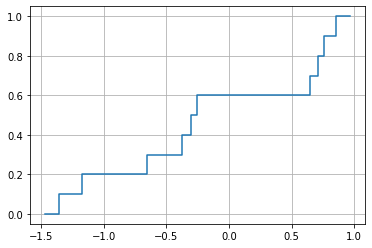

In [95]:
sample = stats.uniform.rvs(-2, 3, size=10)
stats.ecdf(sample).cdf.plot(pyplot)
pyplot.grid()

2. Постройте реализации выборок объемами 10, 100 и 1000 и в одной системе координат постройте графики реализаций эмпирической функции распределения.

3. Постройте гистограмму для одной реализации выборки объёмом 100.

(array([0.06, 0.1 , 0.12, 0.13, 0.11, 0.04, 0.09, 0.17, 0.18]),
 array([-2.        , -1.66666667, -1.33333333, -1.        , -0.66666667,
        -0.33333333,  0.        ,  0.33333333,  0.66666667,  1.        ]),
 <BarContainer object of 9 artists>)

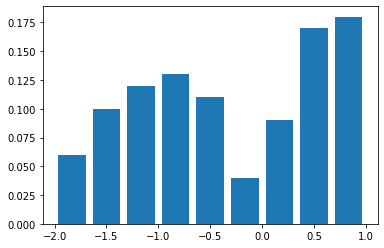

In [114]:
sample = stats.uniform.rvs(-2, 3, size=100)
bins = numpy.linspace(-2, 1, 10)
counts, _ = numpy.histogram(sample, bins=bins)
counts = counts / sample.size
pyplot.hist(bins[:-1], bins, weights=counts, rwidth=0.8)

4. По одной реализации выборки объемом 100 вычислите реализации выборочного среднего, выборочной дисперсии, выборочного начального момента 2-го порядка. Сравните вычисленные величины с точными значениями математического ожидания, дисперсии и второго начального момента 2-го порядка.

In [120]:
a, b = -2, 1
sample = stats.uniform.rvs(a, b-a, size=100)
m_1 = stats.moment(sample, order=1, center=0)
mu_2 = stats.moment(sample, order=2, center=mean)
m_2 = stats.moment(sample, order=2, center=0)
print(f'{"1ый начальный":20}{m_1:.3f} - {(a+b)/2:.3f}')
print(f'{"2ой центральный":20}{mu_2:.3f} - {(b-a)**2/12:.3f}')
print(f'{"2ой начальный":20}{m_2:.3f} - {(b**3-a**3)/(3*(b-a)):.3f}')

1ый начальный       -0.388 - -0.500
2ой центральный     0.802 - 0.750
2ой начальный       0.947 - 1.000


## Задача 2

По выборке $(\xi_1, \dots, \xi_n)$ из биномиального распределения Бернулли $Be(p)$ вычисляется оценка вероятности:
$$
    \widehat{p} = \frac{1}{n} \sum \limits_{i=1}^n \xi_i.
$$

Выберите произвольным образом значение вероятности $p$.

Постройте 20 реализаций выборки объемами $𝑛_1 = 10$ и $𝑛_2 = 50$, для всех реализаций вычислите оценку $\widehat{p}$.

В одной системе координат на двух прямых, параллельных оси абсцисс и пересекающие ось ординат в точках $(0, 𝑛_1)$ и $(0, 𝑛_2)$, отметьте точками (маркерами) все полученные значения оценки для объема выборки $𝑛_1$ и для объема выборки $𝑛_2$ соответственно. В этой же системе координат проведите три прямые параллельные оси ординат и пересекающие ось абсцисс в точках,
соответствующих двум средним арифметическим значений оценки $\widehat{p}$ для объемов $𝑛_1$ и $𝑛_2$, а также точному значению параметра $p$.

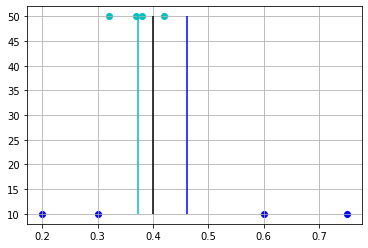

In [ ]:
p = 0.4
n_1, n_2 = 10, 50
p_1 = numpy.array([0.7, 0.2, 0.3, 0.6])
p_2 = numpy.array([0.37, 0.42, 0.32, 0.38])

pyplot.scatter(p_1, [n_1]*len(p_1), color='b')
pyplot.scatter(p_2, [n_2]*len(p_2), color='c')
pyplot.vlines([p_1.mean(), p_2.mean(), p], n_1, n_2, colors=['b', 'c', 'k'])
pyplot.grid()

## Задача 3

По выборке $(\xi_1, \dots, \xi_n)$ из показательного распределения $E(\lambda)$ вычисляются оценки параметра $\lambda$:
$$
    \overline{\lambda}_k(\zeta_n) = \sqrt[k]{\frac{k!}{\widehat{m}_k(\zeta_n)}} , \\
    \widehat{m}_k(\zeta_n) = \frac{1}{n} \sum_{i=1}^n \xi_i^k,
$$

Постройте 50 реализаций объёма $n=100$. Для каждого $k$ от 1 до 20 вычислите 50 значений оценки $\widehat{\lambda}_k$, используя построенные реализации, вычислите среднеквадратические отклонения значений оценки $\sigma_k$ и постройте график значений $\sigma_k$ в зависимости от $k$.

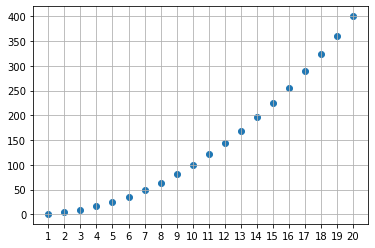

In [122]:
k = numpy.array(range(1,21))
s = k**2
pyplot.scatter(k, s)
pyplot.xticks(range(1,21))
pyplot.grid()

## Задача 4

По выборке $(\xi_1, \dots, \xi_n)$ из равномерного распределения $𝑅[a, b]$ построены три оценки двумерного параметра $(a,b)$.

Методом моментов:
$$
    \overline{a} = \widehat{m}_1 - \sqrt{3 \widehat{\mu}_2}, \\
    \overline{b} = \widehat{m}_1 + \sqrt{3 \widehat{\mu}_2} .
$$

Методом порядковых статистик:
$$
    \widetilde{a} = \frac{p_2 \widetilde{x}_{p_1} - p_1 \widetilde{x}_{p_2}}{p_2 - p_1}, \\
    \widetilde{b} = \frac{(1-p_2) \widetilde{x}_{p_1} - (1 - p_1) \widetilde{x}_{p_2}}{p_1 - p_2} ,
$$
где $p_1$ и $p_2$ --- уровни квантилей (можно выбрать произвольным образом), а $\widetilde{x}_{p_1}$ и $\widetilde{x}_{p_2}$ --- выборочные квантили уровней $p_1$ и $p_2$ --- порядковые статистики $\xi_{(np_1+1)}$ и $\xi_{(np_2+1)}$.

Методом максимального правдоподобия:
$$
    \widehat{a} = \xi_{(1)}, \\
    \widehat{b} = \xi_{(n)} .
$$

Выберите произвольным образом значения $a$ и $b$.

Постройте по 20 реализаций выборок объемов $n_1 = 10$, $n_2 = 50$ и $n_3 = 100$ и для всех реализаций выборок вычислите соответствующие значения всех трех оценок.

Для каждого объема выборки в отдельной системе координат изобразите вычисленные значения трех оценок в виде маркеров, расположенных на трех разных прямых параллельных оси абсцисс (поскольку каждая оценка является двумерной статистикой, то на одной и той же прямой располагаются и значения оценки $a$ и значения оценки для компоненты $b$). В каждой системе координат проведите две прямые параллельные оси ординат и пересекающие ось абсцисс в точках $a$ и $b$. Все три системы координат должны иметь одинаковый масштаб.

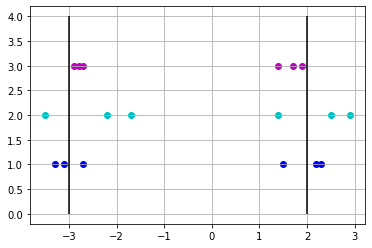

In [123]:
a, b = -3, 2
a_m = [-2.7, -3.3, -3.1]
b_m = [2.2, 1.5, 2.3]
a_q = [-3.5, -1.7, -2.2]
b_q = [1.4, 2.9, 2.5]
a_l = [-2.8, -2.9, -2.7]
b_l = [1.4, 1.9, 1.7]
pyplot.scatter(a_m, [1]*len(a_m), color='b')
pyplot.scatter(b_m, [1]*len(b_m), color='b')
pyplot.scatter(a_q, [2]*len(a_q), color='c')
pyplot.scatter(b_q, [2]*len(b_q), color='c')
pyplot.scatter(a_l, [3]*len(a_l), color='m')
pyplot.scatter(b_l, [3]*len(b_l), color='m')
pyplot.vlines([a, b], 0, 4, colors=['k', 'k'])
pyplot.grid()

Для каждого объема выборки и каждой оценки вычислите среднеквадратическое отклонение полученных значений оценок. Постройте в одной системе координат три ломанных, каждая из которых отражает зависимость среднеквадратических отклонений оценок от объема выборки $n$, откладывая значения среднеквадратических отклонений по оси ординат и объемы выборок по оси абсцисс. На основе построенных ломаных укажите, какая оценка из трех построенных кажется наилучшей.

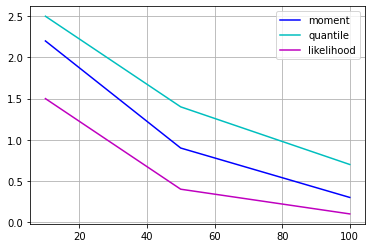

In [124]:
s_m = [2.2, 0.9, 0.3]
s_q = [2.5, 1.4, 0.7]
s_l = [1.5, 0.4, 0.1]
n = [10, 50, 100]
pyplot.plot(n, s_m, color='b', label='moment')
pyplot.plot(n, s_q, color='c', label='quantile')
pyplot.plot(n, s_l, color='m', label='likelihood')
pyplot.legend()
pyplot.grid()